### First set of imports 

In [2]:
import pandas as pd 
from sklearn.model_selection import train_test_split
import os
import json
import torch 
import torch.nn as nn
import numpy as np

pd.set_option("display.max_colwidth", None)



### Convert videos json to df

In [3]:
#Get the videos json
videos = os.path.join("..", "Videos.json")

#Open the json
with open(videos, "r", encoding="utf-8") as f:
    data = json.load(f)

#Turn the json into a pandas dataframe with proper headings     
df = pd.json_normalize(data["videos"])

print(df.columns)
print(df.head())

### Get all the handlandmark paths 

Index(['id', 'Sign', 'filepath', 'HamNoSys', 'concept_url', 'HandLandmark'], dtype='str')
   id      Sign  \
0   1     April   
1   2    Athens   
2   3    August   
3   4    Berlin   
4   5  February   

                                                             filepath  \
0     C:\Users\mccor\Documents\Y4\Dis\Project\Data\External\April.mp4   
1    C:\Users\mccor\Documents\Y4\Dis\Project\Data\External\Athens.mp4   
2    C:\Users\mccor\Documents\Y4\Dis\Project\Data\External\August.mp4   
3    C:\Users\mccor\Documents\Y4\Dis\Project\Data\External\Berlin.mp4   
4  C:\Users\mccor\Documents\Y4\Dis\Project\Data\External\February.mp4   

                                          HamNoSys  \
0     
1                 
2         
3                                         
4                             

                               

### Get hand landmark paths

In [4]:
#find the path to each landmark json in the videos json
Hand_Landmarks_paths = df["HandLandmark"]

Hand_Landmarks = [p for p in Hand_Landmarks_paths if os.path.exists(p)]

print(Hand_Landmarks_paths)


0           C:\Users\mccor\Documents\Y4\Dis\Project\Data\Interim\April_hands.json
1          C:\Users\mccor\Documents\Y4\Dis\Project\Data\Interim\Athens_hands.json
2          C:\Users\mccor\Documents\Y4\Dis\Project\Data\Interim\August_hands.json
3          C:\Users\mccor\Documents\Y4\Dis\Project\Data\Interim\Berlin_hands.json
4        C:\Users\mccor\Documents\Y4\Dis\Project\Data\Interim\February_hands.json
                                          ...                                    
1003          C:\Users\mccor\Documents\Y4\Dis\Project\Data\Interim\yes_hands.json
1004    C:\Users\mccor\Documents\Y4\Dis\Project\Data\Interim\yesterday_hands.json
1005          C:\Users\mccor\Documents\Y4\Dis\Project\Data\Interim\you_hands.json
1006        C:\Users\mccor\Documents\Y4\Dis\Project\Data\Interim\young_hands.json
1007         C:\Users\mccor\Documents\Y4\Dis\Project\Data\Interim\zero_hands.json
Name: HandLandmark, Length: 1008, dtype: str


### Use all those paths to get the jsons and convert them to df

In [5]:

#Empty list for storing each dataframe of the handlandmarks
landmarks_dfs = []

for path in Hand_Landmarks:
    
    with open(path, "r") as f:
        data = json.load(f)
        
    #Create dataframes
    temp_df = pd.json_normalize(data)
    temp_df["source"] = path
    
    landmarks_dfs.append(temp_df)

### Combine all those dfs into one big df

In [6]:
#Take each handlandmark df and make it into one big df
Landmark_df = pd.concat(landmarks_dfs, ignore_index=True)

### Create df with all the frames, landmarks, timings ect.

In [7]:
Hand_rows = []
Pose_rows = []  
Face_rows = []

chunk_size = 100000
first_face_write = True

# For each video
for _, video_row in Landmark_df.iterrows():
    video_path = video_row["video_path"]
    fps = video_row["fps"]
    source = video_row.get("source", None)
    
    for frame in video_row["frames"]:
        frame_index = frame["frame_index"]
        time_sec = frame["time_sec"]

# ====================== Hands =======================
        for hand in frame["hands"]:
            for lm in hand["landmarks"]:
                Hand_rows.append({
                    "video_path": video_path,
                    "fps": fps,
                    "source": source,
                    "frame_index": frame_index,
                    "time_sec": time_sec,
                    "hand_index": hand["hand_index"],
                    "handedness": hand["handedness"],
                    "handedness_score": hand["handedness_score"],
                    "landmark_id": lm["id"],
                    "landmark_name": lm["name"],
                    "x": lm["x"],
                    "y": lm["y"],
                    "z": lm["z"],
                })

# ====================== Face =======================
        for face in frame["face"]:
            for feature in face["landmarks"]:
                Face_rows.append({
                    "video_path": video_path,
                    "fps": fps,
                    "source": source,
                    "frame_index": frame_index,
                    "time_sec": time_sec,
                    "landmark_id": feature["id"],
                    "landmark_name": feature["name"],
                    "x": feature["x"],
                    "y": feature["y"],
                    "z": feature["z"],
                })

  
                if len(Face_rows) >= chunk_size:
                    df_chunk = pd.DataFrame(Face_rows)
                    df_chunk.to_csv(
                        "face_landmarks.csv",
                        mode="a",
                        header=first_face_write,
                        index=False
                    )
                    first_face_write = False
                    Face_rows = []  

# ====================== Pose =======================
        for pose in frame["pose"]:
            for point in pose["landmarks"]:
                Pose_rows.append({
                    "video_path": video_path,
                    "fps": fps,
                    "source": source,
                    "frame_index": frame_index,
                    "time_sec": time_sec,
                    "landmark_id": point["id"],
                    "landmark_name": point["name"],
                    "x": point["x"],
                    "y": point["y"],
                    "z": point["z"],
                    "visibility": point["visibility"],
                })


if Face_rows:
    pd.DataFrame(Face_rows).to_csv(
        "face_landmarks.csv",
        mode="a",
        header=first_face_write,
        index=False
    )


Hand_landmarks_df = pd.DataFrame(Hand_rows)
Pose_landmark_df = pd.DataFrame(Pose_rows)

In [8]:
print(Hand_landmarks_df.columns)
print(Pose_landmark_df.columns)



Index(['video_path', 'fps', 'source', 'frame_index', 'time_sec', 'hand_index',
       'handedness', 'handedness_score', 'landmark_id', 'landmark_name', 'x',
       'y', 'z'],
      dtype='str')
Index(['video_path', 'fps', 'source', 'frame_index', 'time_sec', 'landmark_id',
       'landmark_name', 'x', 'y', 'z', 'visibility'],
      dtype='str')


In [9]:
Pose_landmark_df.head(10)

,video_path,fps,source,frame_index,time_sec,landmark_id,landmark_name,x,y,z,visibility
0,C:\Users\mccor\Documents\Y4\Dis\Project\Data\External\April.mp4,25.0,C:\Users\mccor\Documents\Y4\Dis\Project\Data\Interim\April_hands.json,0,0.0,0,NOSE,0.510578,0.295792,-0.881302,0.997492
1,C:\Users\mccor\Documents\Y4\Dis\Project\Data\External\April.mp4,25.0,C:\Users\mccor\Documents\Y4\Dis\Project\Data\Interim\April_hands.json,0,0.0,1,LEFT_EYE_INNER,0.526559,0.257555,-0.840093,0.992920
2,C:\Users\mccor\Documents\Y4\Dis\Project\Data\External\April.mp4,25.0,C:\Users\mccor\Documents\Y4\Dis\Project\Data\Interim\April_hands.json,0,0.0,2,LEFT_EYE,0.537569,0.257439,-0.840731,0.993055
3,C:\Users\mccor\Documents\Y4\Dis\Project\Data\External\April.mp4,25.0,C:\Users\mccor\Documents\Y4\Dis\Project\Data\Interim\April_hands.json,0,0.0,3,LEFT_EYE_OUTER,0.548740,0.257996,-0.840765,0.993307
4,C:\Users\mccor\Documents\Y4\Dis\Project\Data\External\April.mp4,25.0,C:\Users\mccor\Documents\Y4\Dis\Project\Data\Interim\April_hands.json,0,0.0,4,RIGHT_EYE_INNER,0.491835,0.258954,-0.839670,0.995097
5,C:\Users\mccor\Documents\Y4\Dis\Project\Data\External\April.mp4,25.0,C:\Users\mccor\Documents\Y4\Dis\Project\Data\Interim\April_hands.json,0,0.0,5,RIGHT_EYE,0.481485,0.259623,-0.840395,0.996522
6,C:\Users\mccor\Documents\Y4\Dis\Project\Data\External\April.mp4,25.0,C:\Users\mccor\Documents\Y4\Dis\Project\Data\Interim\April_hands.json,0,0.0,6,RIGHT_EYE_OUTER,0.471080,0.261994,-0.841020,0.996838
7,C:\Users\mccor\Documents\Y4\Dis\Project\Data\External\April.mp4,25.0,C:\Users\mccor\Documents\Y4\Dis\Project\Data\Interim\April_hands.json,0,0.0,7,LEFT_EAR,0.561995,0.269937,-0.566687,0.997734
8,C:\Users\mccor\Documents\Y4\Dis\Project\Data\External\April.mp4,25.0,C:\Users\mccor\Documents\Y4\Dis\Project\Data\Interim\April_hands.json,0,0.0,8,RIGHT_EAR,0.456347,0.279169,-0.562955,0.996100
9,C:\Users\mccor\Documents\Y4\Dis\Project\Data\External\April.mp4,25.0,C:\Users\mccor\Documents\Y4\Dis\Project\Data\Interim\April_hands.json,0,0.0,9,MOUTH_LEFT,0.531493,0.331084,-0.771568,0.998735


### Convert hand landmark df to df seperated by frames and not landmark (will work better for models such as LSTM)

In [10]:
# ================= HANDS =================
Hand_wide_df = Hand_landmarks_df.pivot_table(
    index=["video_path", "frame_index", "time_sec", "source"],
    columns=["handedness", "landmark_name"],
    values=["x", "y", "z"]
)

# Flatten hand columns
Hand_wide_df.columns = [
    f"{hand}_{landmark}_{axis}"
    for axis, hand, landmark in Hand_wide_df.columns
]


# ================= POSE =================
Pose_wide_df = Pose_landmark_df.pivot_table(
    index=["video_path", "frame_index", "time_sec", "source"],
    columns=["landmark_name"],
    values=["x", "y", "z"]
)

# Flatten pose columns
Pose_wide_df.columns = [
    f"{landmark}_{axis}"
    for axis, landmark in Pose_wide_df.columns
]


# ================= COMBINE =================
wide_df = Hand_wide_df.join(Pose_wide_df, how="outer")

# Reset index
wide_df = wide_df.reset_index()

# Fill missing values
wide_df = wide_df.fillna(0.0)



In [11]:
del Hand_wide_df
del Pose_wide_df
del Pose_landmark_df
del Hand_landmarks_df
del Landmark_df 
del Hand_Landmarks_paths
import gc
gc.collect()

0

In [12]:
print(wide_df.head())
print(wide_df.shape)

                                                        video_path  \
0  C:\Users\mccor\Documents\Y4\Dis\Project\Data\External\April.mp4   
1  C:\Users\mccor\Documents\Y4\Dis\Project\Data\External\April.mp4   
2  C:\Users\mccor\Documents\Y4\Dis\Project\Data\External\April.mp4   
3  C:\Users\mccor\Documents\Y4\Dis\Project\Data\External\April.mp4   
4  C:\Users\mccor\Documents\Y4\Dis\Project\Data\External\April.mp4   

   frame_index  time_sec  \
0            0      0.00   
1            1      0.04   
2            2      0.08   
3            3      0.12   
4            4      0.16   

                                                                  source  \
0  C:\Users\mccor\Documents\Y4\Dis\Project\Data\Interim\April_hands.json   
1  C:\Users\mccor\Documents\Y4\Dis\Project\Data\Interim\April_hands.json   
2  C:\Users\mccor\Documents\Y4\Dis\Project\Data\Interim\April_hands.json   
3  C:\Users\mccor\Documents\Y4\Dis\Project\Data\Interim\April_hands.json   
4  C:\Users\mccor\Documents\Y4

###  breaks down that df into features

In [13]:
feature_cols = [col for col in wide_df.columns
                if col not in ["video_path", "frame_index", "time_sec","source"]]

sequences = []
video_ids = []

for video, group in wide_df.groupby("video_path"):
    
    group = group.sort_values("frame_index")
    seq = group[feature_cols].values
    sequences.append(seq)
    video_ids.append(video)
    
print(len(sequences)) 
print(sequences[0].shape)

    

1008
(245, 225)


###  pad out video frames to match the longets video (may need to do some adjusting for models)

In [14]:
# First reduce all sequences
sequences = [seq[::3] for seq in sequences]

# Now compute correct max length
max_len = max(seq.shape[0] for seq in sequences)
num_features = sequences[0].shape[1]

x = np.zeros((len(sequences), max_len, num_features), dtype=np.float32)

for i, seq in enumerate(sequences):
    length = seq.shape[0]
    x[i, :length, :] = seq

print(x.shape)

(1008, 674, 225)


### Convert into a tensor object

In [15]:
X_tensor = torch.tensor(x, dtype=torch.float32)

print(X_tensor.shape)

torch.Size([1008, 674, 225])


In [16]:

video_dict = {
    os.path.basename(fp): ham
    for fp, ham in zip(df["filepath"], df["HamNoSys"])
}
print(video_dict)

{'April.mp4': '\ue0e8\ue0e2\ue002\ue00d\ue0e7\ue002\ue00c\ue0e3\ue0e2\ue027\ue03d\ue0e7\ue031\ue03c\ue0e6\ue03b\ue0e3\ue0e2\ue070\ue077\ue0e7\ue071\ue075\ue0e3\ue0d1\ue051\ue0e2\ue0aa\ue006\ue03c\ue0e7\ue0aa\ue002\ue00d\ue03a\ue0e3\ue080\ue0c6\ue0bb\ue0e2\ue071\ue077\ue0e7\ue071\ue075\ue0e3\ue0d1', 'Athens.mp4': '\ue0e9\ue0e2\ue000\ue00c\ue028\ue03b\ue0e7\ue001\ue00c\ue02a\ue038\ue0e3\ue0e2\ue067\ue0e7\ue075\ue070\ue0e3\ue0d0\ue084\ue0c6\ue0e2\ue067\ue0e7\ue075\ue070\ue0e3\ue0d1\ue0e2\ue080\ue0c6\ue0e7\ue0af\ue0e3\ue0d8', 'August.mp4': '\ue0e8\ue0dd\ue0e2\ue002\ue00d\ue0e7\ue001\ue00c\ue0e3\ue0e2\ue031\ue028\ue03d\ue0e7\ue031\ue03a\ue0e3\ue0e2\ue070\ue077\ue0e7\ue071\ue077\ue0e3\ue0d1\ue051\ue0aa\ue005\ue00d\ue0e0\ue097\ue0aa\ue000\ue00d\ue0e1\ue0e2\ue074\ue079\ue0e7\ue071\ue079\ue0e3\ue0d1', 'Berlin.mp4': '\ue001\ue00d\ue027\ue03e\ue042\ue0d1\ue0e2\ue0aa\ue021\ue03e\ue0e3', 'February.mp4': '\ue0e9\ue003\ue00d\ue028\ue03c\ue0e2\ue077\ue072\ue0e7\ue076\ue072\ue0e3\ue0d1\ue0e2\ue093\ue0a

In [17]:
y_raw = []

for vid in video_ids:
    filename = os.path.basename(vid)
    hamnosys = video_dict[filename]
    y_raw.append(hamnosys)
    
print(y_raw)

['\ue0e8\ue0e2\ue002\ue00d\ue0e7\ue002\ue00c\ue0e3\ue0e2\ue027\ue03d\ue0e7\ue031\ue03c\ue0e6\ue03b\ue0e3\ue0e2\ue070\ue077\ue0e7\ue071\ue075\ue0e3\ue0d1\ue051\ue0e2\ue0aa\ue006\ue03c\ue0e7\ue0aa\ue002\ue00d\ue03a\ue0e3\ue080\ue0c6\ue0bb\ue0e2\ue071\ue077\ue0e7\ue071\ue075\ue0e3\ue0d1', '\ue0e9\ue0e2\ue000\ue00c\ue028\ue03b\ue0e7\ue001\ue00c\ue02a\ue038\ue0e3\ue0e2\ue067\ue0e7\ue075\ue070\ue0e3\ue0d0\ue084\ue0c6\ue0e2\ue067\ue0e7\ue075\ue070\ue0e3\ue0d1\ue0e2\ue080\ue0c6\ue0e7\ue0af\ue0e3\ue0d8', '\ue0e8\ue0dd\ue0e2\ue002\ue00d\ue0e7\ue001\ue00c\ue0e3\ue0e2\ue031\ue028\ue03d\ue0e7\ue031\ue03a\ue0e3\ue0e2\ue070\ue077\ue0e7\ue071\ue077\ue0e3\ue0d1\ue051\ue0aa\ue005\ue00d\ue0e0\ue097\ue0aa\ue000\ue00d\ue0e1\ue0e2\ue074\ue079\ue0e7\ue071\ue079\ue0e3\ue0d1', '\ue001\ue00d\ue027\ue03e\ue042\ue0d1\ue0e2\ue0aa\ue021\ue03e\ue0e3', '\ue0e9\ue003\ue00d\ue028\ue03c\ue0e2\ue077\ue072\ue0e7\ue076\ue072\ue0e3\ue0d1\ue0e2\ue093\ue0aa\ue008\ue020\ue03d\ue0e3\ue076\ue070\ue0d1', '\ue009\ue00d\ue010\ue020

In [18]:
print(y_raw[0])
print(len(y_raw[0]))



47


In [19]:
all_tokens = set()

for seq in y_raw:
    for char in seq:
        all_tokens.add(char)

print(len(all_tokens))

176


In [20]:
token_to_id = {token: i+3 for i, token in enumerate(sorted(all_tokens))}

# special tokens
token_to_id["<PAD>"] = 0
token_to_id["<SOS>"] = 1
token_to_id["<EOS>"] = 2

vocab_size = len(token_to_id)

id_to_token = {i: t for t, i in token_to_id.items()}

print(list(token_to_id.items())[:10])

[('\ue000', 3), ('\ue001', 4), ('\ue002', 5), ('\ue003', 6), ('\ue004', 7), ('\ue005', 8), ('\ue006', 9), ('\ue007', 10), ('\ue008', 11), ('\ue009', 12)]


In [21]:
y_sequences = []

for seq in y_raw:
    encoded = [token_to_id["<SOS>"]]
    
    for char in seq:
        encoded.append(token_to_id[char])
        
    encoded.append(token_to_id["<EOS>"])
    
    y_sequences.append(encoded)
    
    
print(y_sequences[0])
print(len(token_to_id))



[1, 176, 170, 5, 16, 175, 5, 15, 171, 170, 30, 46, 175, 40, 45, 174, 44, 171, 170, 83, 90, 175, 84, 88, 171, 157, 66, 170, 131, 9, 45, 175, 131, 5, 16, 43, 171, 94, 149, 141, 170, 84, 90, 175, 84, 88, 171, 157, 2]
179


In [22]:
max_len = max(len(seq) for seq in y_sequences)
print(max_len)

135


In [23]:

y_padded = np.zeros((len(y_sequences), max_len), dtype=int)

for i, seq in enumerate(y_sequences):
    y_padded[i, :len(seq)] = seq

In [56]:
import torch 
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import Adam #Do I keep adam or GD
import matplotlib.pyplot as plt
import seaborn as sns
import lightning as L
from torch.utils.data import TensorDataset, DataLoader

import random
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


### Splitting Data into Train, Val, Test

In [57]:
# First, split into train + temp (val+test)
X_train, X_temp, y_train, y_temp = train_test_split(
    sequences, y_sequences, test_size=0.3, random_state=42
)

# Then split temp into validation and test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print("Train:", len(X_train), "Validation:", len(X_val), "Test:", len(X_test))

Train: 705 Validation: 151 Test: 152


### Trims rubbish from sequence

In [58]:
def trim_at_eos(seqs, eos_token):
    trimmed = []
    for seq in seqs:
        if eos_token in seq:
            idx = seq.index(eos_token)
            trimmed.append(seq[:idx+1])  # keep EOS
        else:
            trimmed.append(seq)  # no EOS found, keep as is
    return trimmed


### Creates windows so that we can expand dataset

In [ ]:
def create_windows(X_sequences, y_sequences, window_size=100, stride=50):
    X_new = []
    y_new = []

    for x_seq, y_seq in zip(X_sequences, y_sequences):

        seq_len = x_seq.shape[0]

        for start in range(0, seq_len - window_size + 1, stride):
            end = start + window_size

            x_window = x_seq[start:end]

    
            y_window = y_seq

            X_new.append(x_window) 
            y_new.append(y_window) 
    return X_new, y_new

# Keeping the split
x_train_aug, y_train_aug = create_windows(X_train, y_train)
x_val_aug, y_val_aug = create_windows(X_val,y_val)
x_test_aug, y_test_aug = create_windows(X_test,y_test)

### Padding sequences 

In [ ]:

def pad_sequences(seqs):
    max_len = max(seq.shape[0] for seq in seqs) 
    num_features = seqs[0].shape[1] 

    X = np.zeros((len(seqs), max_len, num_features), dtype=np.float32) 

    for i, seq in enumerate(seqs): 
        X[i, :seq.shape[0], :] = seq

    return torch.tensor(X)

def pad_labels(labels, pad_token=0):
    max_len = max(len(seq) for seq in labels) 

    Y = np.full((len(labels), max_len), pad_token) 

    for i, seq in enumerate(labels): 
        Y[i, :len(seq)] = seq

    return torch.tensor(Y, dtype=torch.long)

y_train_trimmed = trim_at_eos(y_train_aug, token_to_id["<EOS>"])
y_val_trimmed   = trim_at_eos(y_val_aug,   token_to_id["<EOS>"])
y_test_trimmed  = trim_at_eos(y_test_aug,  token_to_id["<EOS>"])

X_train_tensor = pad_sequences(x_train_aug)
X_val_tensor   = pad_sequences(x_val_aug)
X_test_tensor  = pad_sequences(x_test_aug)

y_train_tensor = pad_labels(y_train_trimmed)
y_val_tensor   = pad_labels(y_val_trimmed)
y_test_tensor  = pad_labels(y_test_trimmed)

### Wraps Tensors

In [61]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

### Batches of 16 of the wrapped Tensors

In [62]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)
test_loader = DataLoader(test_dataset,batch_size=16)

### Encoder Class - Summary of frames for decoder class

In [63]:
class Encoder(nn.Module):
    def __init__(self, input_size, hidden_size=256, num_layers=2):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size,
            hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.3
        )

    def forward(self, x):
        outputs, (hidden, cell) = self.lstm(x)
        return outputs, hidden, cell


### Decoder Class - Looks at the memory and assigns tokens

In [ ]:
class Decoder(nn.Module):
    def __init__(self, vocab_size, hidden_size=256, num_layers=2):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.embedding = nn.Embedding(vocab_size, hidden_size)

        self.attn = nn.Linear(hidden_size * 2, hidden_size)
        self.attn_norm = nn.LayerNorm(hidden_size)
        self.v = nn.Linear(hidden_size, 1, bias=False)

        self.lstm = nn.LSTM(
            hidden_size * 2,
            hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.3
        )

        self.fc = nn.Linear(hidden_size, vocab_size)

    def attention(self, hidden, encoder_outputs):
        hidden = hidden[-1].unsqueeze(1)  
        seq_len = encoder_outputs.size(1)

        hidden = hidden.repeat(1, seq_len, 1)

        energy = torch.tanh(self.attn(torch.cat((hidden, encoder_outputs), dim=2)))
        energy = self.attn_norm(energy)
        attention = self.v(energy).squeeze(2)
        return torch.softmax(attention, dim=1)

    def forward(self, x, hidden, cell, encoder_outputs):
        x = self.embedding(x).unsqueeze(1)

        attn_weights = self.attention(hidden, encoder_outputs)
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs)

        lstm_input = torch.cat((x, context), dim=2)

        output, (hidden, cell) = self.lstm(lstm_input, (hidden, cell))
        prediction = self.fc(output.squeeze(1))

        return prediction, hidden, cell, attn_weights


### Loss function

In [65]:
criterion = nn.CrossEntropyLoss(ignore_index=token_to_id["<PAD>"]) #Loss function

### Seq2seq - Runs encoder and decoder

In [ ]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, vocab_size):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.vocab_size = vocab_size

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        batch_size = src.size(0)
        trg_len = trg.size(1)

        outputs = torch.zeros(batch_size, trg_len, self.vocab_size).to(src.device)
        all_attn = []

        encoder_outputs, hidden, cell = self.encoder(src)

        input_token = trg[:, 0]  

        src_len = src.size(1)  
        coverage = torch.zeros(batch_size, src_len, device=src.device)
        coverage_losses = []


        for t in range(1, trg_len):
            output, hidden, cell, attn = self.decoder(
                input_token, hidden, cell, encoder_outputs
            )

            outputs[:, t] = output
            all_attn.append(attn)
            
            coverage_loss = torch.sum(torch.min(attn, coverage), dim=1)
            coverage_losses.append(coverage_loss)

            coverage = coverage + attn


            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(1)

            input_token = trg[:, t] if teacher_force else top1

        return outputs, torch.stack(all_attn, dim=1), torch.stack(coverage_losses, dim=1)



### Connects it all together

In [73]:
num_features = X_tensor.shape[2]  # detect input features
hidden_size = 128 

encoder = Encoder(input_size=num_features, hidden_size=hidden_size)
decoder = Decoder(vocab_size=vocab_size, hidden_size=hidden_size)

model = Seq2Seq(encoder, decoder, vocab_size)


### Updated weights based on loss function

In [74]:
optimiser = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5) #Dynamic weights

In [75]:
def token_accuracy(output, trg, pad_idx=0):
    
    pred = output.argmax(1)
    mask = trg != pad_idx
    correct = (pred == trg) & mask
    accuracy = correct.sum().item()/mask.sum().item()
    return accuracy*100

In [ ]:
best_val_loss = float("inf")
patience = 3
patience_counter = 0
num_epochs = 100
lambda_cov = 0.1  # coverage weight

for epoch in range(num_epochs):

    model.train()
    train_loss = 0

    teacher_forcing_ratio = max(0.05, 0.5 * (0.90 ** epoch))

    for src, trg in train_loader:
        src, trg = src.to(device), trg.to(device)

        optimiser.zero_grad()

        output, attn, cov_loss = model(src, trg, teacher_forcing_ratio=teacher_forcing_ratio)

        flat_output = output[:, 1:, :].reshape(-1, output.shape[-1])
        flat_trg = trg[:, 1:].reshape(-1)

        ce_loss = criterion(flat_output, flat_trg)
        coverage_penalty = cov_loss.mean() * lambda_cov

        loss = ce_loss + coverage_penalty
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)
        optimiser.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # validation
    model.eval()
    val_loss = 0
    total_acc = 0
    num_batches = 0
    min_len = 5

    with torch.no_grad():
        for src, trg in val_loader:
            src, trg = src.to(device), trg.to(device)

            output, attn, cov_loss = model(src, trg, teacher_forcing_ratio=0)

            pred_ids = output.argmax(2)
            sample_idx = 0

            decoded = []
            for t, token_id in enumerate(pred_ids[sample_idx]):
                token = id_to_token[token_id.item()]
                if t > min_len and token == "<EOS>":
                    break
                if token not in ["<PAD>", "<SOS>"]:
                    decoded.append(token)

            true_tokens = []
            for t, token_id in enumerate(trg[sample_idx]):
                token = id_to_token[token_id.item()]
                if t > min_len and token == "<EOS>":
                    break
                if token not in ["<PAD>", "<SOS>"]:
                    true_tokens.append(token)

            print("PRED:", decoded)
            print("TRUE:", true_tokens)

            flat_output = output[:, 1:, :].reshape(-1, output.shape[-1])
            flat_trg = trg[:, 1:].reshape(-1)

            loss = criterion(flat_output, flat_trg)
            val_loss += loss.item()

            total_acc += token_accuracy(flat_output, flat_trg)
            num_batches += 1

    val_loss /= num_batches
    acc = total_acc / num_batches

    print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Acc: {acc:.2f}%")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_model.pt")
        print("New best model saved")
    else:
        patience_counter += 1
        print(f"No improvement ({patience_counter}/{patience})")
        if patience_counter >= patience:
            print("Early stopping triggered — training stopped")
            break


PRED: ['\ue0e9', '\ue0e6', '\ue03d', '\ue03d', '\ue0e3', '\ue031', '\ue090', '\ue0e3', '\ue088', '\ue00e', '\ue00e', '\ue00e', '\ue03d', '\ue067', '\ue0d6', '\ue088', '\ue088', '\ue03e', '\ue067']
TRUE: ['\ue0e9', '\ue002', '\ue00e', '\ue011', '\ue0e6', '\ue002', '\ue00e', '\ue027', '\ue03c', '\ue042', '\ue059', '\ue0d1', '\ue0e2', '\ue084', '\ue0aa', '\ue028', '\ue0e6', '\ue029', '\ue051', '\ue0e3']
PRED: ['\ue0e9', '\ue0e9', '\ue0e6', '\ue03d', '\ue0e3', '\ue031', '\ue0e3', '\ue090', '\ue0e3', '\ue088', '\ue088', '\ue03e', '\ue00e', '\ue00e', '\ue03d', '\ue03d', '\ue067', '\ue0d6', '\ue088', '\ue088']
TRUE: ['\ue0e2', '\ue001', '\ue028', '\ue03e', '\ue0e7', '\ue001', '\ue02a', '\ue03a', '\ue0e3', '\ue067', '\ue088', '\ue0d1']
Epoch 1, Train Loss: 5.2722, Val Loss: 5.1518, Acc: 9.14%
New best model saved
PRED: ['\ue0e9', '\ue0e9', '\ue0e6', '\ue0e6', '\ue0e3', '\ue0e3', '\ue0e3', '\ue0e3', '\ue031', '\ue0e3', '\ue0e3', '\ue0e3', '\ue031', '\ue0e3', '\ue0e3']
TRUE: ['\ue0e9', '\ue002',

### Validation

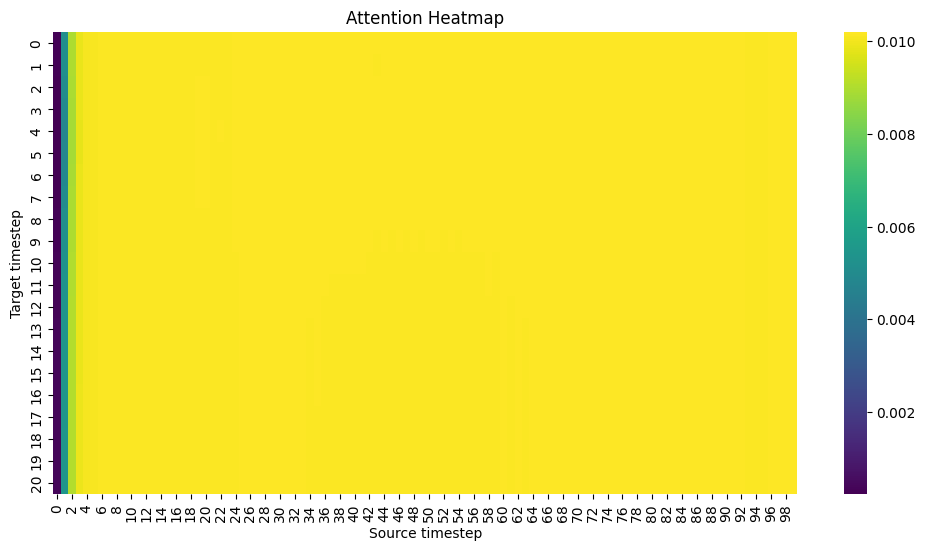

In [52]:
attn_matrix = attn[0].detach().cpu().numpy()

plt.figure(figsize=(12, 6))
sns.heatmap(attn_matrix, cmap="viridis")
plt.xlabel("Source timestep")
plt.ylabel("Target timestep")
plt.title("Attention Heatmap")
plt.show()


In [53]:
print((trg == 0).sum(), "/", trg.numel())

tensor(9) / 44
